In [1]:
# STEP 1: Imports

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# STEP 2: Dataset
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

100%|██████████| 170M/170M [00:02<00:00, 62.3MB/s] 


In [3]:
# STEP 3: Prunable Linear Layer

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Strong negative init for pruning
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2.3)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gate_values(self):
        return torch.sigmoid(self.gate_scores)

In [4]:
# STEP 4: CNN Model

class PrunableCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = PrunableLinear(64 * 8 * 8, 256)
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

    def get_all_gates(self):
        return torch.cat([
            self.fc1.get_gate_values().view(-1),
            self.fc2.get_gate_values().view(-1)
        ])

In [5]:
# STEP 5: Loss Function

def compute_loss(model, outputs, targets, lambda_l1):
    ce_loss = F.cross_entropy(outputs, targets)

    gates = model.get_all_gates()

    # Controlled sparsity
    sparsity_loss = torch.mean(gates)

    return ce_loss + lambda_l1 * sparsity_loss

In [6]:
# STEP 6: Training

def train_model(lambda_l1, epochs=20):
    model = PrunableCNN().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=8e-4)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = compute_loss(model, outputs, labels, lambda_l1)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.2f}")

    return model

In [7]:
# STEP 7: Evaluation

def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [8]:
# STEP 8: Sparsity Calculation

def calculate_sparsity(model, threshold=0.07):
    gates = model.get_all_gates()
    total = gates.numel()

    pruned = (gates < threshold).sum().item()

    return (pruned / total) * 100


In [9]:
# STEP 9: Run Experiments

lambdas = [0.05, 0.1, 0.2]
results = []

for lam in lambdas:
    print(f"\n Training with lambda = {lam}")

    model = train_model(lam)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    print(f" Accuracy: {acc:.2f}%")
    print(f" Sparsity: {sparsity:.2f}%")

    # Debug gate values
    gates = model.get_all_gates().detach().cpu()
    print("Gate stats → Min:", gates.min().item(),
          "Mean:", gates.mean().item(),
          "Max:", gates.max().item())

    results.append((lam, acc, sparsity))


 Training with lambda = 0.05
Epoch 1/20 | Loss: 743.36
Epoch 2/20 | Loss: 619.01
Epoch 3/20 | Loss: 576.04
Epoch 4/20 | Loss: 544.64
Epoch 5/20 | Loss: 520.63
Epoch 6/20 | Loss: 496.80
Epoch 7/20 | Loss: 477.11
Epoch 8/20 | Loss: 455.39
Epoch 9/20 | Loss: 438.61
Epoch 10/20 | Loss: 422.81
Epoch 11/20 | Loss: 408.48
Epoch 12/20 | Loss: 395.31
Epoch 13/20 | Loss: 387.16
Epoch 14/20 | Loss: 377.01
Epoch 15/20 | Loss: 370.44
Epoch 16/20 | Loss: 361.59
Epoch 17/20 | Loss: 353.64
Epoch 18/20 | Loss: 346.62
Epoch 19/20 | Loss: 341.68
Epoch 20/20 | Loss: 336.45
 Accuracy: 68.52%
 Sparsity: 61.53%
Gate stats → Min: 0.000617238343693316 Mean: 0.08866152167320251 Max: 0.911366879940033

 Training with lambda = 0.1
Epoch 1/20 | Loss: 747.74
Epoch 2/20 | Loss: 625.64
Epoch 3/20 | Loss: 581.68
Epoch 4/20 | Loss: 550.38
Epoch 5/20 | Loss: 521.95
Epoch 6/20 | Loss: 500.33
Epoch 7/20 | Loss: 480.03
Epoch 8/20 | Loss: 462.12
Epoch 9/20 | Loss: 444.70
Epoch 10/20 | Loss: 428.63
Epoch 11/20 | Loss: 414.7

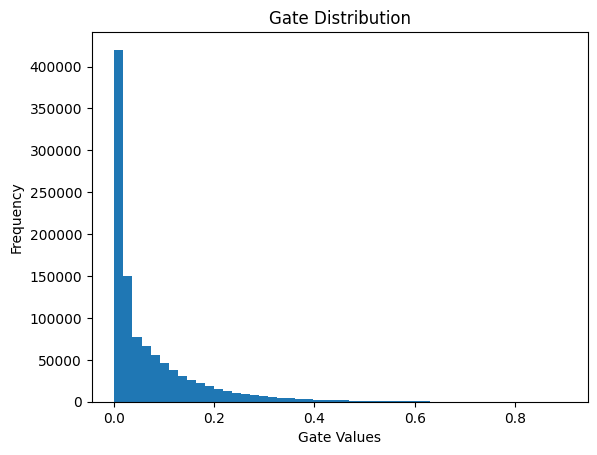

In [10]:
# STEP 10: Plot Gates

def plot_gates(model):
    gates = model.get_all_gates().cpu().detach().numpy()

    plt.hist(gates, bins=50)
    plt.title("Gate Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()

plot_gates(model)